In [1]:
# reading the algerian forest data set uing pandas 

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

dset=pd.read_csv('Algerian_forest_fires_dataset.csv')

dset

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [2]:
dset.loc[:122,"Region"]=0
dset.loc[122:,"Region"]=1
df=dset.dropna().reset_index(drop=True)


In [3]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
240,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
241,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
242,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0


In [4]:
df['Classes  '].unique()
df['Classes  ']=df['Classes  '].str.strip(' ')

In [5]:
df[df['Classes  ']=="Classes"]


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [6]:
# we need to drop the 122 index in the  dataset
df=df.drop(index=122).reset_index(drop=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    object 
 1   month        243 non-null    object 
 2   year         243 non-null    object 
 3   Temperature  243 non-null    object 
 4    RH          243 non-null    object 
 5    Ws          243 non-null    object 
 6   Rain         243 non-null    object 
 7   FFMC         243 non-null    object 
 8   DMC          243 non-null    object 
 9   DC           243 non-null    object 
 10  ISI          243 non-null    object 
 11  BUI          243 non-null    object 
 12  FWI          243 non-null    object 
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(1), object(14)
memory usage: 28.6+ KB


In [8]:
df[['day','month','year']]=df[['day','month','year']].astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    object 
 4    RH          243 non-null    object 
 5    Ws          243 non-null    object 
 6   Rain         243 non-null    object 
 7   FFMC         243 non-null    object 
 8   DMC          243 non-null    object 
 9   DC           243 non-null    object 
 10  ISI          243 non-null    object 
 11  BUI          243 non-null    object 
 12  FWI          243 non-null    object 
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(1), int64(3), object(11)
memory usage: 28.6+ KB


In [10]:
df[['FFMC','DMC','DC','ISI','BUI','FWI']]=df[['FFMC','DMC','DC','ISI','BUI','FWI']].astype(float)

In [11]:
df[['Temperature',' RH',' Ws']]=df[['Temperature',' RH',' Ws']].astype(int)

In [12]:
# df["Rain"]=df["Rain"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4    RH          243 non-null    int64  
 5    Ws          243 non-null    int64  
 6   Rain         243 non-null    object 
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(7), int64(6), object(2)
memory usage: 28.6+ KB


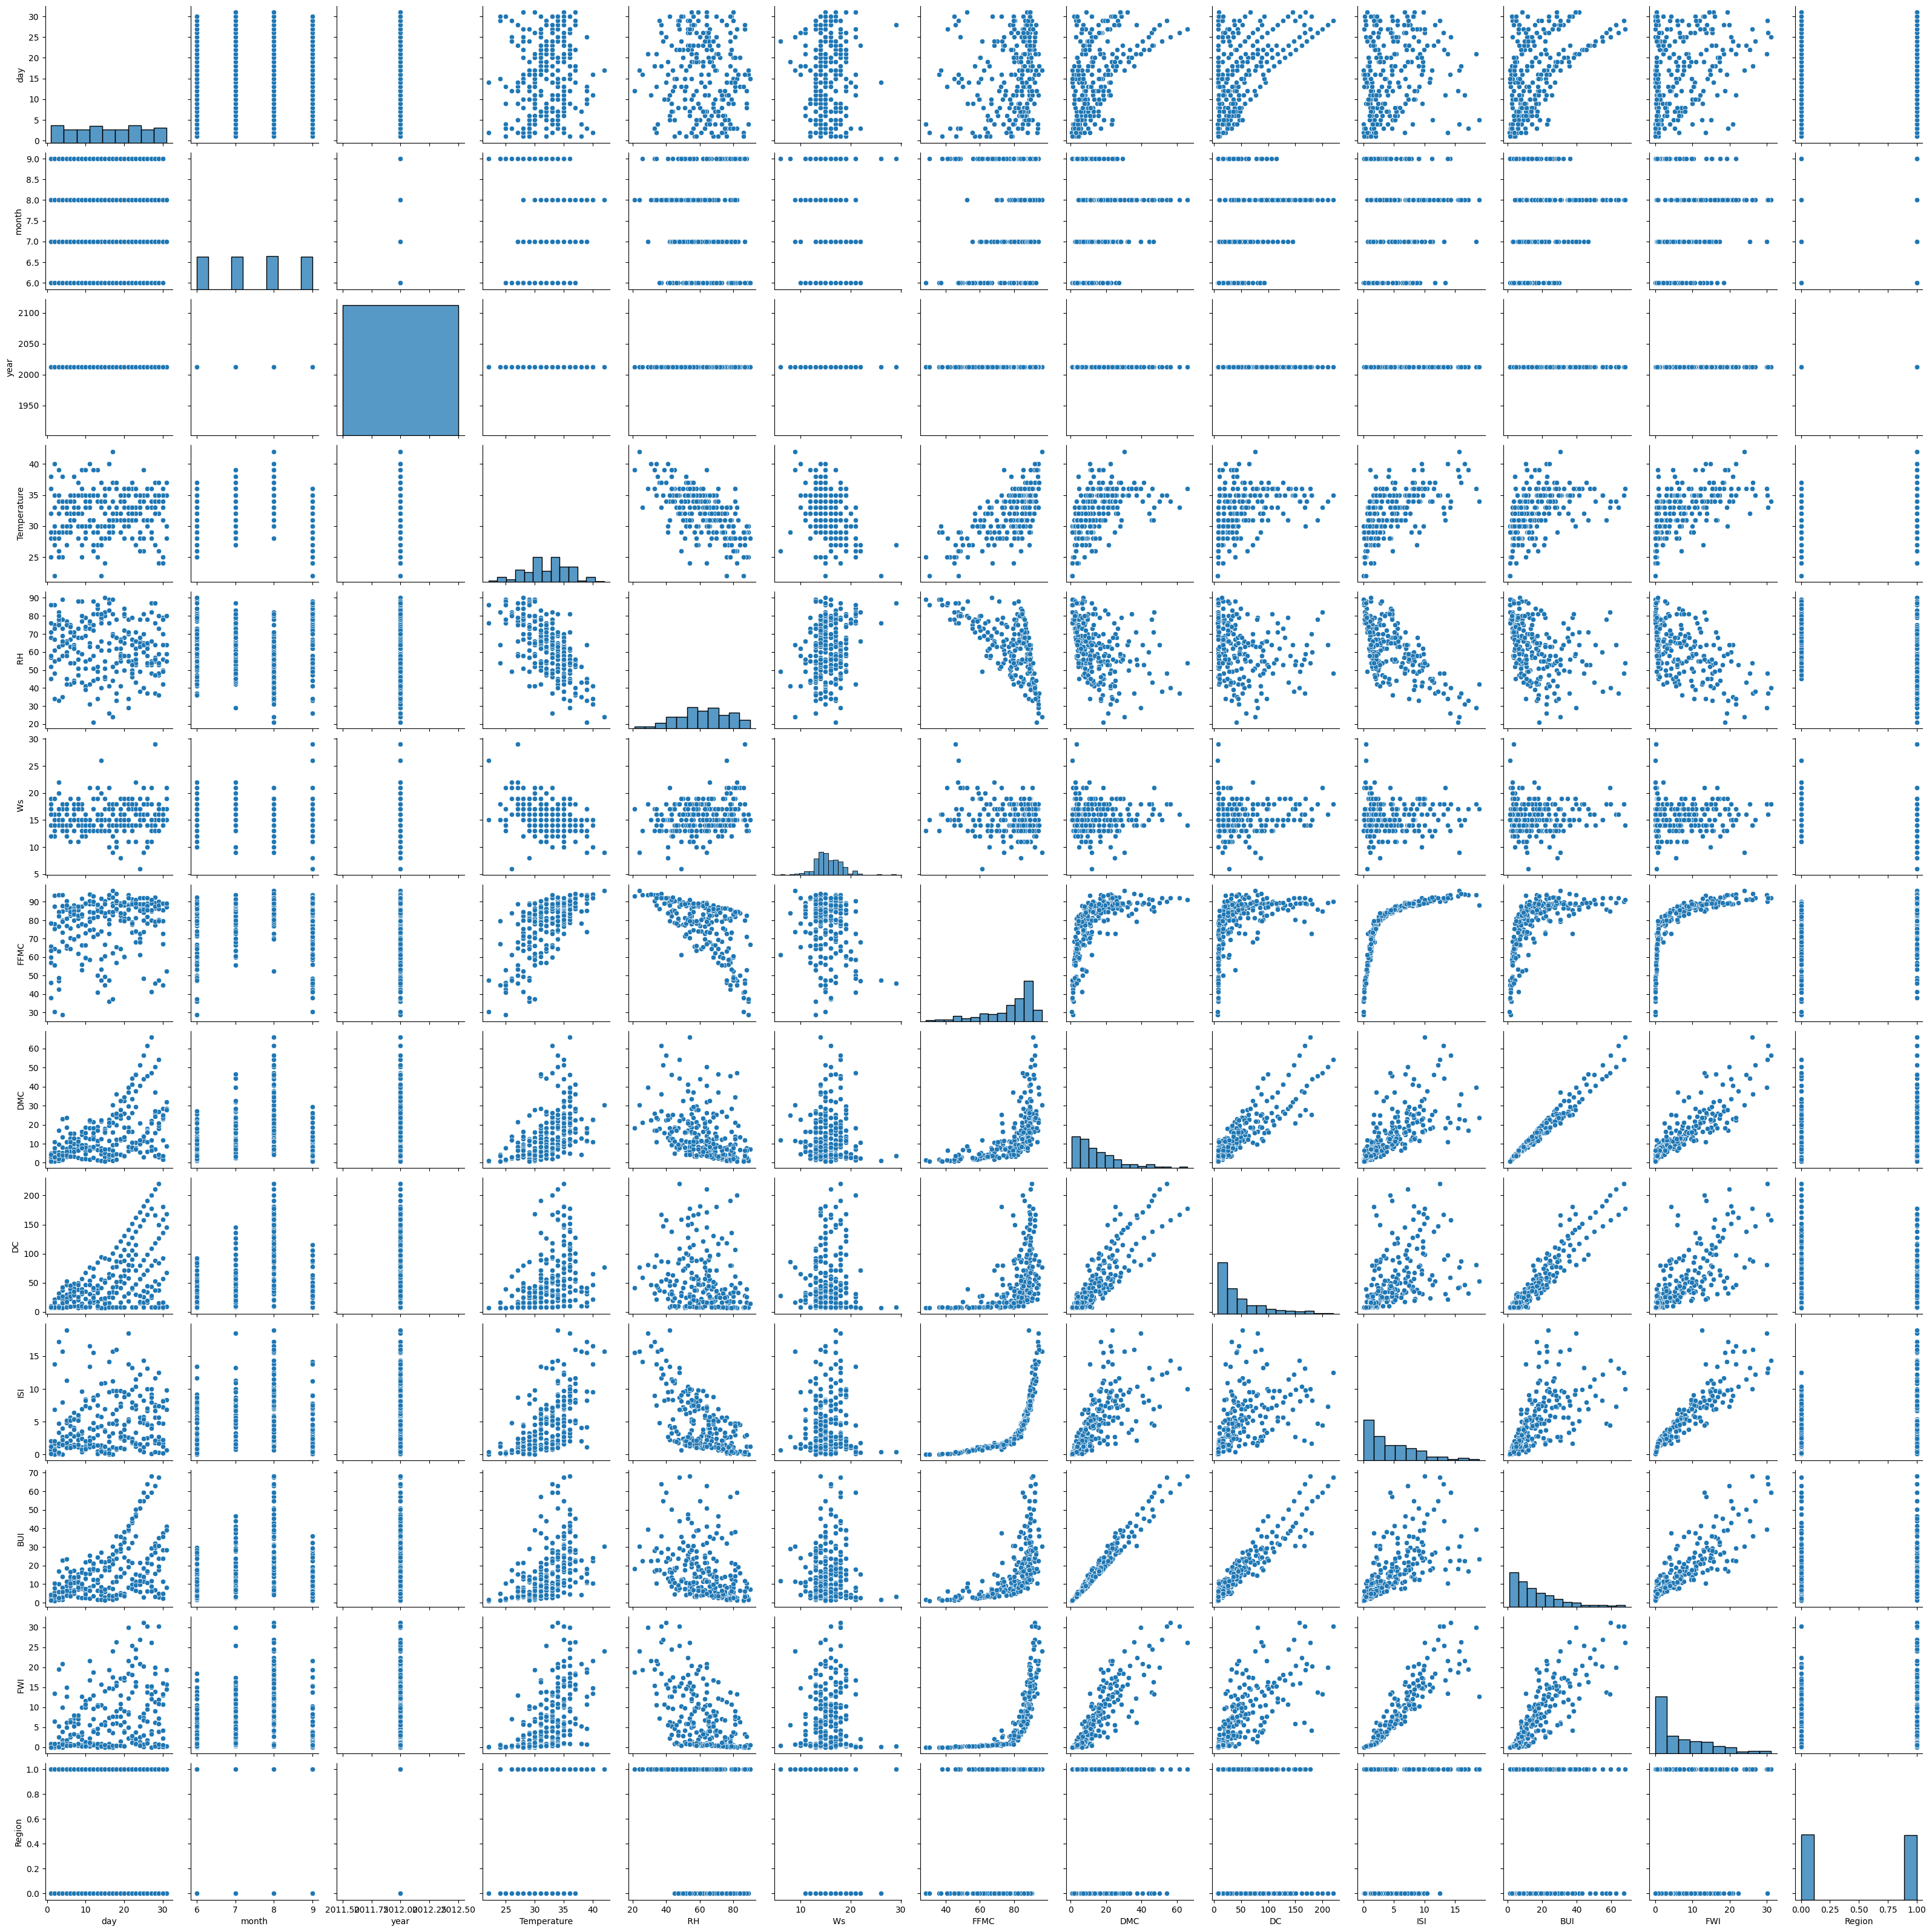

In [13]:
# Explotary dataanalysis

import seaborn as sns

# pair plot 
sns.pairplot(df)

C:\Users\HP\AppData\Local\Temp\ipykernel_9732\1650401231.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df.groupby('Region')['Temperature'].sum()/122,palette='hls')


<Axes: xlabel='Region', ylabel='Temperature'>

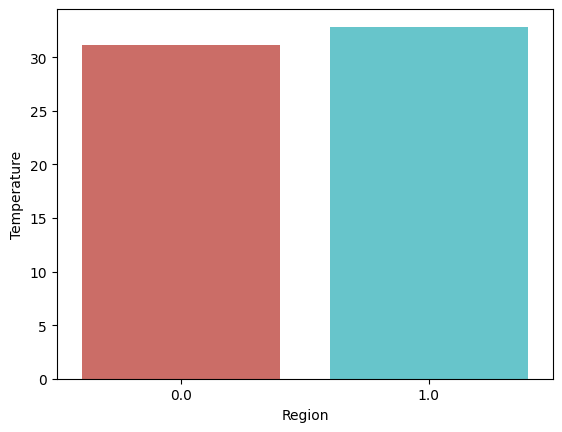

In [14]:
sns.barplot(df.groupby('Region')['Temperature'].sum()/122,palette='hls')


In [15]:
# sns.barplot(df.groupby(['Region','month'])['Rain'].sum())
df['Rain_new']=df['Rain ']


In [16]:
df['Rain_new']=df['Rain_new'].astype(float)

In [17]:
df.drop('Rain ',inplace=True,axis=1)

In [18]:
l1=df.groupby(['Region','month'])['Rain_new'].sum()

In [19]:
#regionwise temperature
l1.reset_index()

plot=pd.DataFrame(l1)

plot.reset_index()


,Region,month,Rain_new
0,0.0,6,24.5
1,0.0,7,7.0
2,0.0,8,19.5
3,0.0,9,51.8
4,1.0,6,34.0
5,1.0,7,20.8
6,1.0,8,8.3
7,1.0,9,19.5


C:\Users\HP\AppData\Local\Temp\ipykernel_9732\1474545327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=[6,7,8,9],x=plot['Rain_new'][0:4],palette='hls',orient='h')
C:\Users\HP\AppData\Local\Temp\ipykernel_9732\1474545327.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=[6,7,8,9],x=plot['Rain_new'][4:],palette='hls',orient='h')


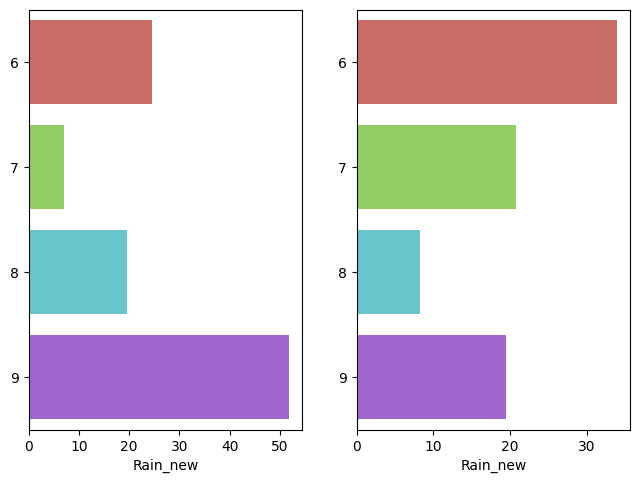

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

plt.subplot(2,3,1)
sns.barplot(y=[6,7,8,9],x=plot['Rain_new'][0:4],palette='hls',orient='h')
plt.xlabel='Region 0'
plt.ylabel='Total_rain'

plt.subplot(2,3,2)
sns.barplot(y=[6,7,8,9],x=plot['Rain_new'][4:],palette='hls',orient='h')
plt.xlabel='Region 1'
plt.ylabel='Total_rain'


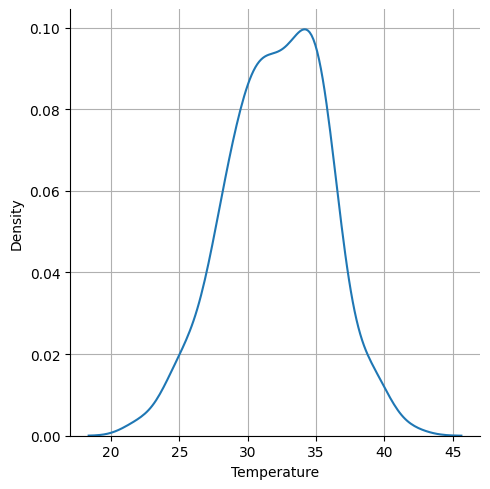

In [21]:
# plot the displot

sns.displot(df['Temperature'],kind='kde')
plt.grid('True')

In [22]:
# heat map for studing the correlation betwwent each component

# now we will drop the classes

list=df['Classes  ']

df.drop('Classes  ',axis=1,inplace=True)



<Axes: >

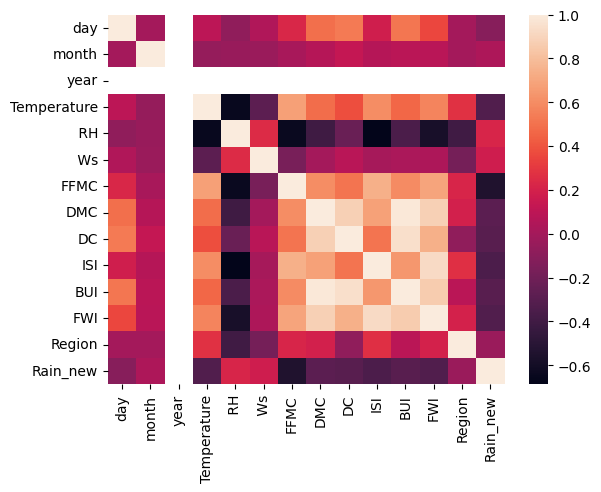

In [23]:
sns.heatmap(df.corr())

In [24]:
# region with the highest rain fal in mm
df.groupby('Region')['Rain_new'].sum()

Region
0.0    102.8
1.0     82.6
Name: Rain_new, dtype: float64

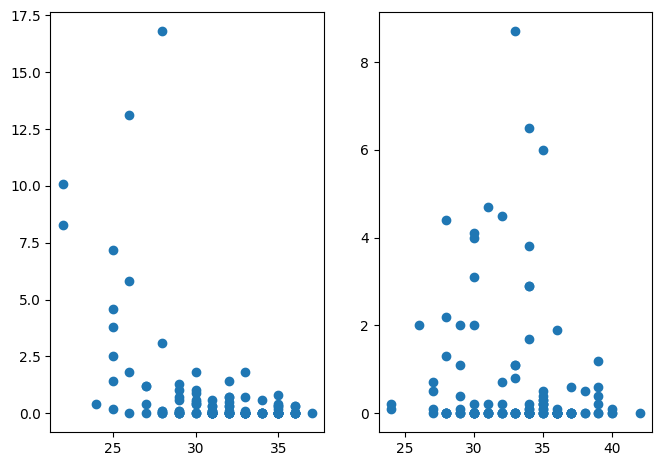

In [25]:
# polt betwwen the temperatutre and  the rainfall

plt.figure(figsize=(12,12))


r1=df[df['Region']==0]
r2=df[df['Region']==1]

plt.subplot(2,3,1)
plt.scatter(r1['Temperature'],r1['Rain_new'])
plt.xlabel='Region 0'


plt.subplot(2,3,2)
plt.scatter(r2['Temperature'],r2['Rain_new'])
plt.xlabel='Region 1'


In [26]:
# saving the clean dataset file

# df.to_csv('clean_algerianforest_dataset.csv')

# saving the clean dataset file

df=pd.read_csv('clean_algerianforest_dataset.csv')

In [27]:
# do the encoding of the classes
df['Classes']=pd.DataFrame(list)

from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder()

encoded=encoder.fit_transform(df[['Classes']]).toarray()

new=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())



new_df=pd.concat([df,new],axis=1)


In [28]:
new_df=pd.concat([df,new],axis=1)
new_df

,Unnamed: 0,day,month,year,Temperature,RH,Ws,FFMC,DMC,DC,ISI,BUI,FWI,Region,Rain_new,Classes,Classes_fire,Classes_not fire
0,0,1,6,2012,29,57,18,65.7,3.4,7.6,1.3,3.4,0.5,0.0,0.0,not fire,0.0,1.0
1,1,2,6,2012,29,61,13,64.4,4.1,7.6,1.0,3.9,0.4,0.0,1.3,not fire,0.0,1.0
2,2,3,6,2012,26,82,22,47.1,2.5,7.1,0.3,2.7,0.1,0.0,13.1,not fire,0.0,1.0
3,3,4,6,2012,25,89,13,28.6,1.3,6.9,0.0,1.7,0.0,0.0,2.5,not fire,0.0,1.0
4,4,5,6,2012,27,77,16,64.8,3.0,14.2,1.2,3.9,0.5,0.0,0.0,not fire,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,238,26,9,2012,30,65,14,85.4,16.0,44.5,4.5,16.9,6.5,1.0,0.0,fire,1.0,0.0
239,239,27,9,2012,28,87,15,41.1,6.5,8.0,0.1,6.2,0.0,1.0,4.4,not fire,0.0,1.0
240,240,28,9,2012,27,87,29,45.9,3.5,7.9,0.4,3.4,0.2,1.0,0.5,not fire,0.0,1.0
241,241,29,9,2012,24,54,18,79.7,4.3,15.2,1.7,5.1,0.7,1.0,0.1,not fire,0.0,1.0


In [29]:
r1=df[df['Region']==0]
r2=df[df['Region']==1]

count1=pd.DataFrame(r1.groupby(['month','Classes'])['Classes'].count()).reset_index(name='count')

count1['Classes']

# sns.barplot(x=count1['month'],y=count1['Classes'],palette='hls')
# plt.title('Region 1',weight='bold')
# plt.xlabel='Region 0'


# plt.subplot(2,3,2)
# plt.scatter(r2['Temperature'],r2['Rain_new'])
# plt.xlabel='Region 1'

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [31]:
new_df.to_csv('Forest.csv')